In [47]:
! pip install segmentation-models-pytorch evaluate transformers

In [48]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2 as cv
from glob import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from transformers import get_scheduler
import evaluate
from tqdm import tqdm

In [49]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

In [50]:
class CustomDataset(Dataset):
    def __init__(self, imgs, masks, transform=None):
        self.imgs = imgs
        self.masks = masks
        self.transform = transform


    def __len__(self):
        return len(self.imgs)


    def __getitem__(self, index):
        img = cv.imread(self.imgs[index])
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = cv.resize(img, (256,256))
        img = img.astype('float32') / 255.0

        img = torch.tensor(img).permute(2,0,1)
        
        img_mask = cv.imread(self.masks[index], cv.IMREAD_GRAYSCALE)
        img_mask = cv.resize(img_mask, (256,256))
        img_mask = img_mask.astype('float32') / 255.0
        img_mask = np.expand_dims(img_mask, axis=0)

        img_mask = torch.tensor(img_mask)


        return img,img_mask

In [51]:
images = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input"
images_masks = '/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth'

In [52]:
images_paths = sorted(glob(os.path.join(images,"*jpg")))
images_masks_paths = sorted(glob(os.path.join(images_masks, "*png")))

In [53]:
train_imgs, test_imgs, train_masks, test_masks = train_test_split(images_paths, images_masks_paths, test_size=0.2, random_state=42)

In [54]:
print(len(train_imgs), len(test_imgs), len(train_masks), len(test_masks))

2075 519 2075 519


In [55]:
## Create dataset instances

train_dataset = CustomDataset(train_imgs, train_masks)
test_dataset = CustomDataset(test_imgs, test_masks)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


In [56]:
img, mask = train_dataset[0]

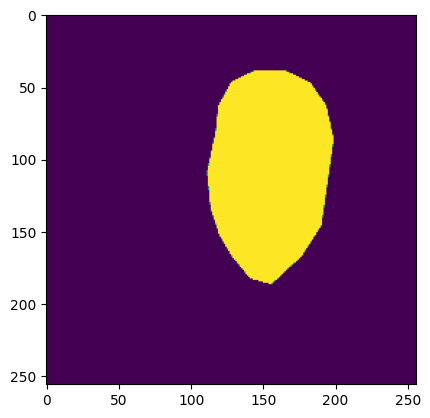

In [57]:
plt.imshow(mask.permute(1,2,0))

In [58]:
class EarlyStopping:
    def __init__(self, patience=5, delta=2e-3):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)
        return model


In [59]:
model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet', in_channels=3, classes=1).to(device)
loss = nn.BCEWithLogitsLoss()


In [60]:
def train(loss, classifier, train_data, val_data, lr, num_epochs=10):
    # Modelo a entrenar
    
    #classifier = Model(input_size).to(device)
    
    # ------------ parámetros
    
    optimizer = optim.AdamW(classifier.parameters(), lr=lr)
    
    num_training_steps = num_epochs * len(train_data)
    
    num_warmup_steps = int(num_training_steps * 0.1)
    
    scheduler = get_scheduler(name="linear", optimizer=optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
    
    early_stop_f = EarlyStopping()
    
    # Listas para guardar las perdidas obtenidas época tras época.
    
    loss_epoch_test = []
    loss_epoch_train = []
    
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}')
        train_loss = 0 
        classifier.train()
    
        # Evaluate para el cálculo de métricas
        metric_train = evaluate.load("accuracy")
        metric_val = evaluate.load("accuracy")
        
        for idx,data in enumerate(tqdm(train_data)):
            
            images = data[0].to(device)
            masks = data[1].to(device)
            
            optimizer.zero_grad()
    
            output = classifier(images)
            training_loss = loss(output, masks) 
            
            training_loss.backward()
            optimizer.step()
            scheduler.step()
    
    
            train_loss += training_loss.item() * images.size(0)
            
            probs = torch.sigmoid(output)
            #predict = (probs > 0.5).float()
            
            #metric_train.add_batch(predictions=predict, references=label)
    
    
        validation_loss = 0
        epoch_loss = train_loss/len(train_data.dataset)
        
        classifier.eval()
        
        for idx, data in enumerate(val_data):
    
            images_val = data[0].to(device)
            masks_val = data[1].to(device)
    
            with torch.no_grad():
                output_val = classifier(images_val)
                val_loss = loss(output_val, masks_val)
                validation_loss += val_loss.item() * images_val.size(0)
    
                probs_val = torch.sigmoid(output_val)
                #predict_val = (probs_val >= 0.5).float()
                
            #metric_val.add_batch(predictions=predict_val, references=label_val)
    
            
        
        validation_loss_avg = validation_loss / len(val_data.dataset) 
                
        loss_epoch_test.append(validation_loss_avg)
        loss_epoch_train.append(epoch_loss)
    
        # Metricas train y validacion
        #acc_train = metric_train.compute()
        #acc_val = metric_val.compute()
    
        ## Resultados de la epoca
        print(f"\n {'-'*4} Epoch {epoch+1} {'-'*4} \n")
        print(f"Train results: \n Train loss: {epoch_loss:.4f}")  
        print(f"Val results: \n Val loss: {validation_loss_avg:.4f}")  
    
        # Early Stopping
        early_stop_f(validation_loss_avg, classifier)
    
        if early_stop_f.early_stop:
            print("Early stopping")
            break
    
    return early_stop_f.load_best_model(classifier),loss_epoch_train, loss_epoch_test
    
    

In [61]:
model_final, train_loss, val_loss = train(loss, model, train_loader, test_loader, lr=1e-4, num_epochs=20)

Epoch 1


100%|██████████| 65/65 [01:53<00:00,  1.74s/it]



 ---- Epoch 1 ---- 

Train results: 
 Train loss: 0.5726
Val results: 
 Val loss: 0.5093
Epoch 2


100%|██████████| 65/65 [01:54<00:00,  1.77s/it]



 ---- Epoch 2 ---- 

Train results: 
 Train loss: 0.3434
Val results: 
 Val loss: 0.3037
Epoch 3


...


 ---- Epoch 12 ---- 

Train results: 
 Train loss: 0.0733
Val results: 
 Val loss: 0.1411
Epoch 13


100%|██████████| 65/65 [01:59<00:00,  1.84s/it]



 ---- Epoch 13 ---- 

Train results: 
 Train loss: 0.0673
Val results: 
 Val loss: 0.1379
Epoch 14


100%|██████████| 65/65 [01:56<00:00,  1.79s/it]



 ---- Epoch 14 ---- 

Train results: 
 Train loss: 0.0693
Val results: 
 Val loss: 0.1388
Early stopping


In [62]:
def segmentate(image_path, model):
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (256,256))
    img = img.astype('float32') / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output).cpu().squeeze().numpy()
        probs = (output > 0.5).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(probs)
    

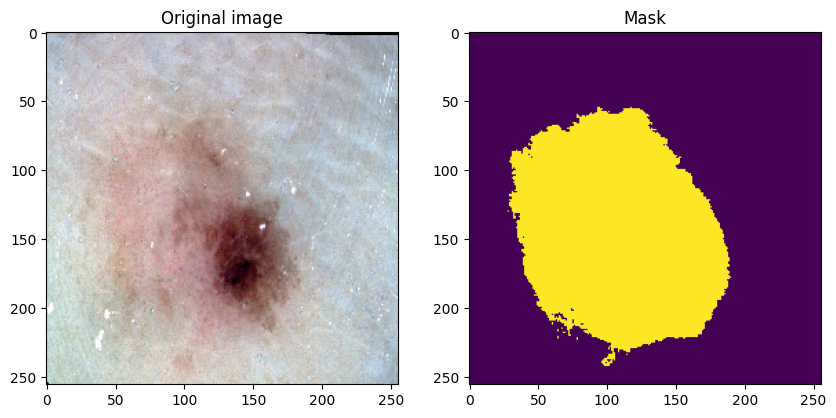

In [76]:
path = '/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Test_Input/ISIC_0015478.jpg'
segmentate(path, model_final )

In [80]:
torch.save(model_final.state_dict(), f"./model_weights_skin_segmentation.pth")